<a href="https://colab.research.google.com/github/edik06031-rgb/DTA_2026/blob/main/classmade/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [17]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({                 # це основна таблична структура даних у Pandas.
    "area": area.round(1),          # площа прмішення округлена до одного знаку після коми.
    # "rooms": rooms.astype(int),   # кількість кімнат,astype()-змінює тип даних, (тип цілі числа)
    "floor": floor,                 # який поверх
    "dist_km": dist_km.round(1),    # округлення відстані до центру міста до одного знака після коми.
    "age_years": age_years,         # колонка з віком будинку.
    "price": price.round(1),        # oкруглення цін до одного знака після коми.
})

df.head()                           # виводить пять перших колонок таблиці

,area,floor,dist_km,age_years,price
0,69.9,6,2.6,14,172.1
1,57.2,11,6.4,30,122.8
2,73.0,3,2.4,54,146.3
3,90.5,8,3.4,13,217.6
4,55.3,3,2.8,10,165.2


In [18]:
df.shape


(1000, 5)

In [19]:
print(f"Розмір таблиці : {df.shape[0]} рядків x {df.shape[1]} стовпчики")          # f - дозволяє вставляти значення змінних прямо в текст.
print("\nЧи є пропуски?")                                                          # "\n" - cимвол нового рядка.
print(df.isna().sum())                                                             # Перевіряє кожну клітинку на пропуск (NaN).Підраховує кількість True.
df.describe().round(2)                                                             # Виводить описову статистику для числових колонок.

Розмір таблиці : 1000 рядків x 5 стовпчики

Чи є пропуски?
area         0
floor        0
dist_km      0
age_years    0
price        0
dtype: int64


,area,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,12.69,4.96,30.39,136.25
std,19.33,7.00,4.71,17.23,44.99
min,20.00,1.00,0.30,0.00,20.00
25%,47.08,6.00,1.50,16.00,104.15
50%,60.50,13.00,3.60,30.00,136.75
75%,73.00,19.00,7.00,45.25,165.45
max,137.10,24.00,25.00,59.00,282.40


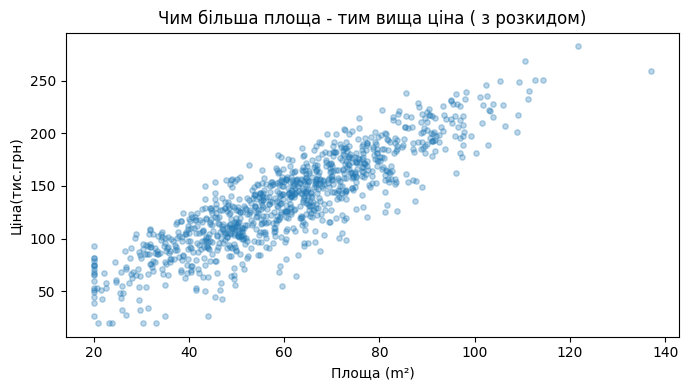

In [20]:
plt.figure(figsize=(7, 4))                                          # Створює нове вікно для графіка.Задає розмір графіка.
plt.scatter(df["area"], df["price"], alpha=0.3,s=15)                # Будує точкову діаграму (scatter plot).Кожна точка = одна квартира,alpha=0.3 - прозорість, s=15 - розмір точок
plt.xlabel("Площа (m²)")                                            # по осі X відкладається площа Підпис осі X.
plt.ylabel("Ціна(тис.грн)")                                         # по осі Y відкладається ціна Підпис осі Y.
plt.title("Чим більша площа - тим вища ціна ( з розкидом)")         # Додає заголовок графіка.
plt.tight_layout()                                                  # Автоматично підбирає відступи.
plt.show()                                                          # Відображає графік на екрані.

In [21]:
from sklearn.model_selection import train_test_split
X = df[['area', 'floor', 'dist_km', 'age_years']]   # feathures - ознаки
y = df['price']   # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Навчальна вибірка:",X_train.shape[0], "квартир")
print("Тестова вибірка :", X_test.shape[0], "квартир")

Навчальна вибірка: 800 квартир
Тестова вибірка : 200 квартир


**from sklearn.model_selection import train_test_split** - Імпортує функцію train_test_split() з бібліотеки Scikit-Learn.
Вона використовується для поділу даних на:навчальну вибірку (train),тестову вибірку (test)

X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']]
**bold text**

X — це ознаки (features), за якими модель буде навчатися.
подвійні квадратні дужки - вибрати кілька колонок
у - створення цільової змінної, y — це те, що модель повинна навчитися прогнозувати(ціна).

**train_test_split()** - Перемішує дані та ділить їх на дві частини:для навчання,
для перевірки

**test_size=0.2**  це означає:

20% даних віддається на тестування.

80% залишається для навчання.


random_state=RANDOM_STATE

Щоб розбиття було однаковим кожного запуску.random_state=42

print("Навчальна вибірка:", X_train.shape[0], "квартир") - Виводить кількість квартир у навчальній вибірці.

print("Тестова вибірка :", X_test.shape[0], "квартир") - Виводить кількість квартир у тестувальній вибірці.






In [22]:
df.columns

Index(['area', 'floor', 'dist_km', 'age_years', 'price'], dtype='object')

LinearRegression


| X | y | **X_train** | X_test | **y_train** | y_test | y_pred |
| - | - | ------- | ------ | ------- | ------ | -- |
| 1 | 1 | 1 |  | 1 |  |  |
| 2 | 4 | 2 |  | 4 |  |  |
| 3 | 9 |  | 3 |  | 9 | 90 |
| 4 | 16 | 4 |  | 16 |  |  |
| 5 | 25 |  | 5 |  | 25 | 250 |
| 6 | 36 | 6 |  | 36 |  |  |
| 7 | 49 | 7 |  | 49 |  |  |
| 8 | 64 | 8 |  | 64 |  |  |
| 9 | 81 | 9 |  | 81 |  |  |
| 10 | 100 | 10 |  | 100 |  |  |
| 11 |  |  |  |  |  | 1210 |


In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "real_price": y_test[:5].round(2) ,
    "predict_price" : y_pred[:5].round(2)
})
compare["error"] = (compare['predict_price'] - compare['real_price']).round(2)
compare

,real_price,predict_price,error
521,119.1,128.64,9.54
737,173.3,178.74,5.44
740,20.0,26.70,6.70
660,93.7,105.78,12.08
411,100.6,95.47,-5.13


from sklearn.linear_model import LinearRegression - Імпортує модель лінійної регресії.

model = LinearRegression() - Створює об'єкт моделі.Поки що модель "порожня" і нічого не знає про дані.

model.fit(X_train, y_train) - **"fit" ** Навчає модель.

що передається - X_train - ознаки квартир (area,floor...age),

Y_train - справжні ціни

y_pred = model.predict(X_test) - робить прогноз ціни на основі ознак нових ( тестових) квартир

compare = pd.DataFrame({...}) - Створення таблиці порівняння
y_test[:5] - бере перші 5 реальних значень.
round(2) - округлює числа до 2 знаків після коми.

y_pred[:5] - перші 5 прогнозів моделі.

compare["error"] = Створює нову колонку.Помилка = Прогноз − Реальна ціна

# метрики для регресії

МАЕ - наскільки в середньому ми помилилися - 7 -> 7 тис.🇺🇸

RMSE - схожу на МАЕ, сильніше карає великі промахи -
менше = краще

R² - яку частину розкиду модель може оцінити - [0.;1.0]
-> 1 - ідеально, 0 - вгадує середній показник

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE = {mae:.1f}тис.$ (у середньому помиляемося на скільки) ")
print(f"MSE = {mse:.1f}")
print(f"RMSE = {rmse:.1f} тис.$")
print(f"R² = {r2:.3f} модель пояснює {r2*100:.1f}% розкиду ціни")

MAE = 9.0тис.$ (у середньому помиляемося на скільки) 
MSE = 130.7
RMSE = 11.4 тис.$
R² = 0.941 модель пояснює 94.1% розкиду ціни


**from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score**

Імпортуються функції для оцінки якості моделі.Після навчання моделі потрібно зрозуміти:

Наскільки добре вона прогнозує ціни?

Для цього використовують метрики.

mean_absolute_error() - "MAE"- Середня абсолютна помилка.
mse = mean_squared_error(y_test, y_pred) - "MSE" - Середня квадратична помилка.


rmse = np.sqrt(mean_squared_error(...)) - Корінь із MSE.

Чому використовують RMSE?

MSE має квадратні одиниці виміру.
Наприклад:(тис.$)^2 - це незручно.

RMSE повертає помилку назад у вихідні одиниці: тис.$

r2 = r2_score(y_test, y_pred) - Коефіцієнт детермінації R²

Показує, наскільки добре модель пояснює дані.Модель пояснює 94.1% змін ціни квартир.Це хороший показник.

{mae:.1f} - Округлення до 1 знака після коми

{r2:.3f} - Округлення до 3 знаків після коми

MAE - відповідає на питання: "На скільки в середньому помиляється модель?"

RMSE -  показує типову величину помилки, сильніше караючи великі промахи.

R² - показує, наскільки добре характеристики квартири (площа, кімнати, поверх, відстань, вік будинку) пояснюють її ціну.

Що означають результати?
у середньому прогноз помиляється на 9 тис.$;

великі помилки враховуються через MSE;

типова помилка становить близько 11.4 тис.$;

модель пояснює 94.1 % варіації цін квартир.













In [25]:
coefs = pd.DataFrame({
    "features" : X.columns,
    "coef": model.coef_.round(2)

}).sort_values("coef", ascending=False)
print(f"Базова ціна : {model.intercept_:.2f} тис.🇺🇸\n")
print("Як кожна ознака впливає на ціну")
coefs

Базова ціна : 43.06 тис.🇺🇸

Як кожна ознака впливає на ціну


,features,coef
0,area,1.97
1,floor,0.38
3,age_years,-0.51
2,dist_km,-3.09


model.coef_ - Після навчання LinearRegression зберігає коефіцієнти моделі.

Кожен коефіцієнт відповідає певній ознаці:

Ознака	Коефіцієнт
area	1.97

floor	0.38

dist_km	  -3.09

age_years -0.51

Якщо коефіцієнт додатний:ціна зростає

Якщо від'ємний:ціна зменшується

Наприклад: area = 1.97

Збільшення площі на 1 м² підвищує прогнозовану ціну приблизно на 1.97 тис. доларів.

round(2) - Округлює коефіцієнти до двох знаків після коми.

X.columns - Повертає назви всіх ознак.

pd.DataFrame() - Створює таблицю коефіцієнтів.

sort_values() - Сортує таблицю за колонкою coef у зворотньому порядку **ascending=False**

model.intercept_ - Вільний член (intercept) лінійної регресії,стартова (базова) ціна, від якої модель відштовхується перед врахуванням ознак.

{model.intercept_:.2f} - Округлює значення до 2 знаків після коми.

In [26]:
price2 = (40.83 + area * 1.78 + rooms * 5.22+ dist_km * (-3.07)+age_years * (0.49) + floor * (0.39))

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)